In [2]:
%pip install pandas matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.4-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.3.0-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ----------- ---------------------------- 2.9/9.7 MB 18.6 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.7 MB 17.5 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 17.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ----------- ---------------------------- 2.6/9.3 MB 13.7 MB/s eta 0:00:01
   ----------------------- ---------------- 5.5/9.3 MB 12.9 MB/s eta 0:00:01
   ----------------------------------- ---- 8.4/9.3 MB 14.1 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 13.5 MB/s

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Shape: (13152, 10)

Columns:
['date', 'product_id', 'category', 'units_sold', 'price', 'competitor_price', 'discount', 'promotion', 'inventory', 'holiday']

Missing values:
date                0
product_id          0
category            0
units_sold          0
price               0
competitor_price    0
discount            0
promotion           0
inventory           0
holiday             0
dtype: int64

Summary statistics:
                      date    product_id    units_sold         price  \
count                13152  13152.000000  13152.000000  13152.000000   
mean   2024-07-01 12:00:00    252.000000     76.605991    759.694643   
min    2023-01-01 00:00:00    101.000000     31.000000    221.000000   
25%    2023-10-01 18:00:00    176.500000     62.000000    466.287500   
50%    2024-07-01 12:00:00    252.000000     74.000000    630.030000   
75%    2025-04-01 06:00:00    327.500000     89.000000    958.890000   
max    2025-12-31 00:00:00    403.000000    188.000000   1620.090000 

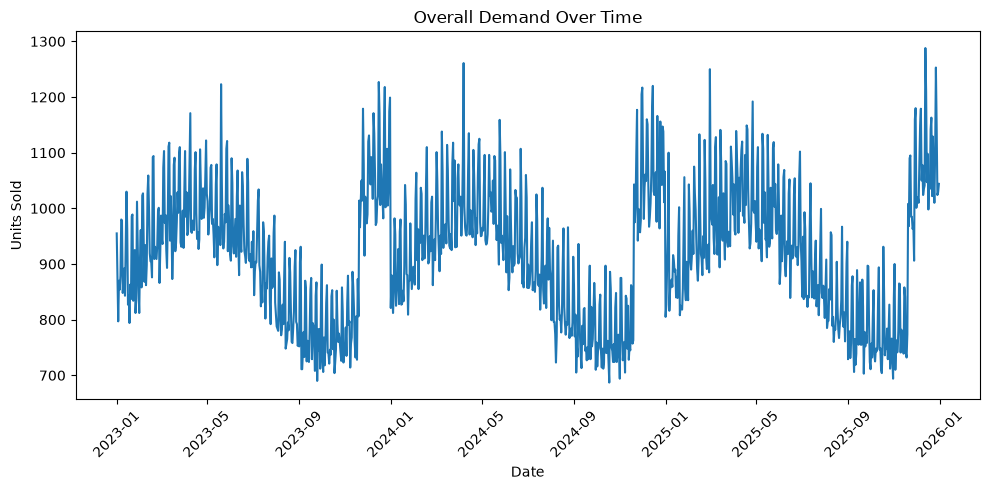

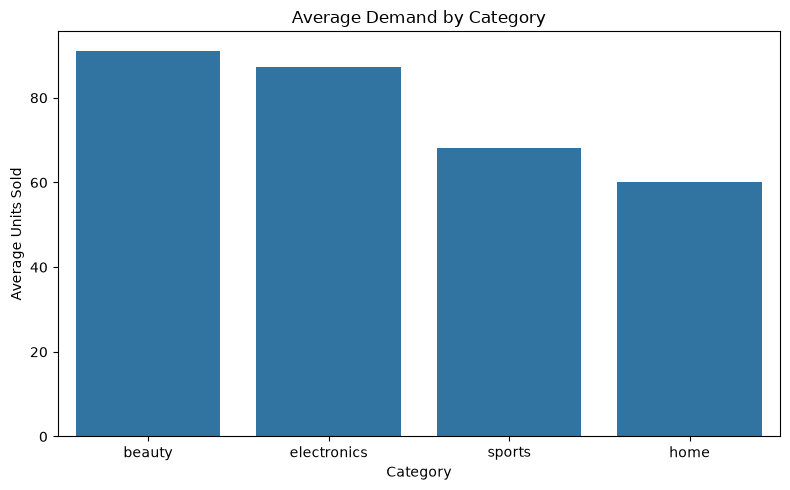

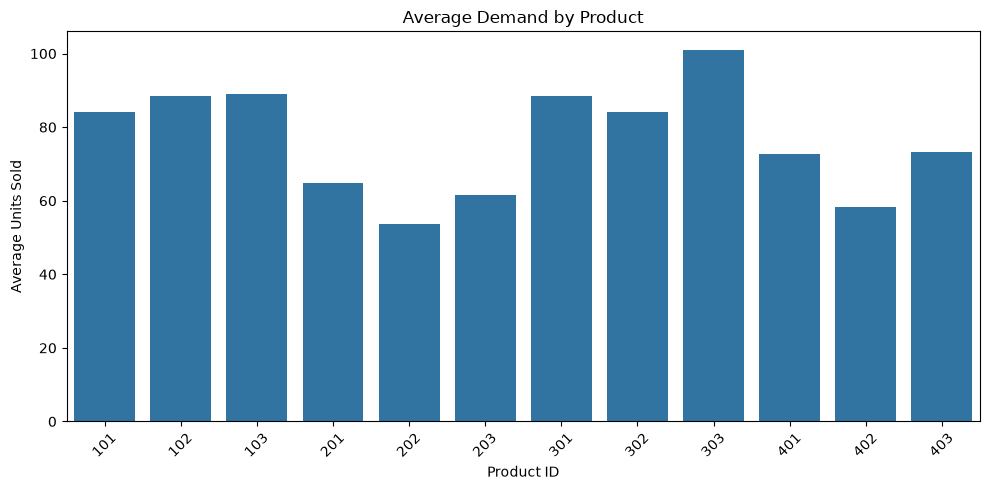

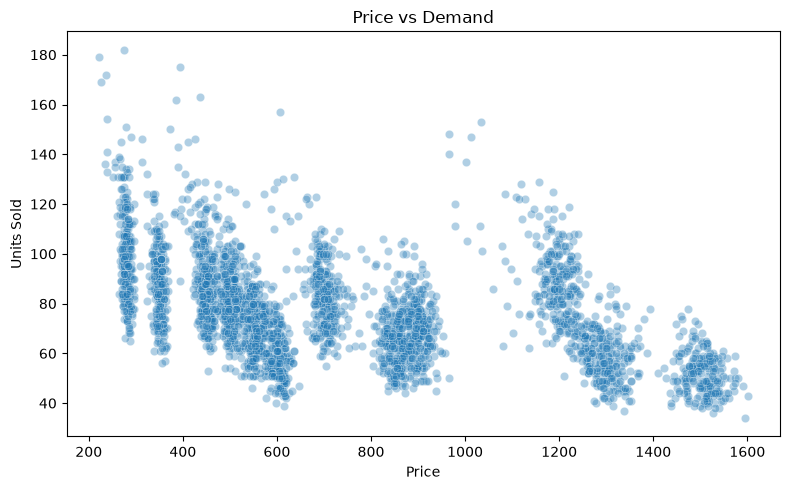

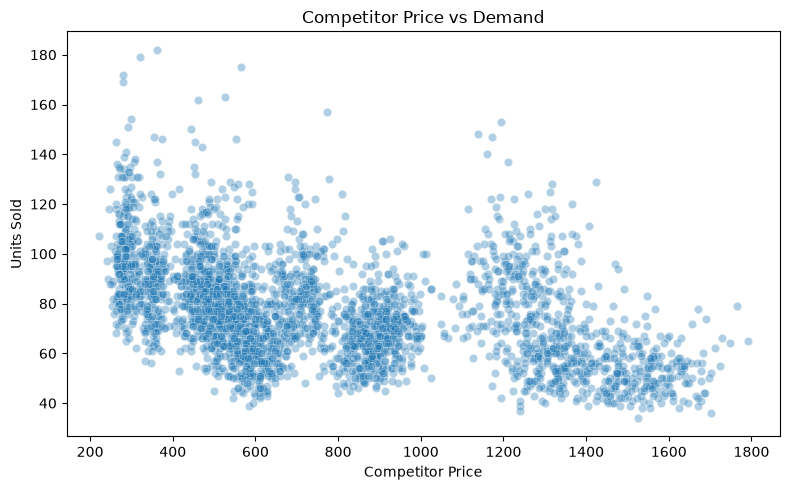

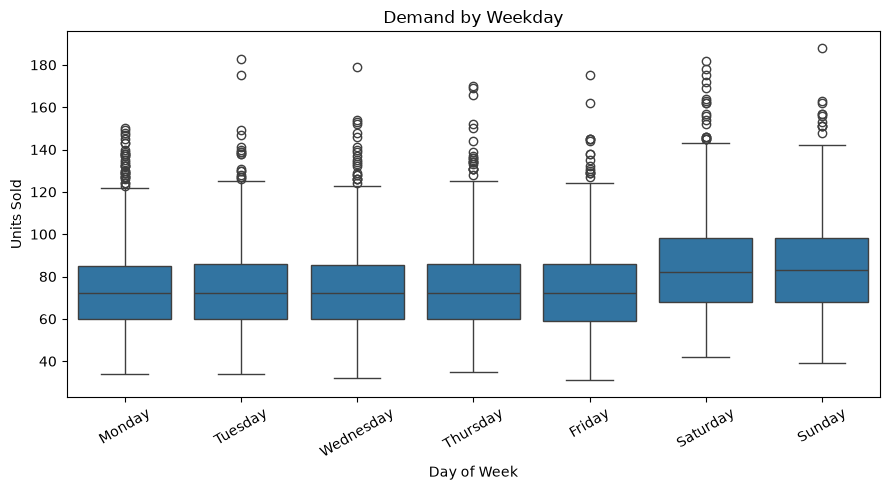

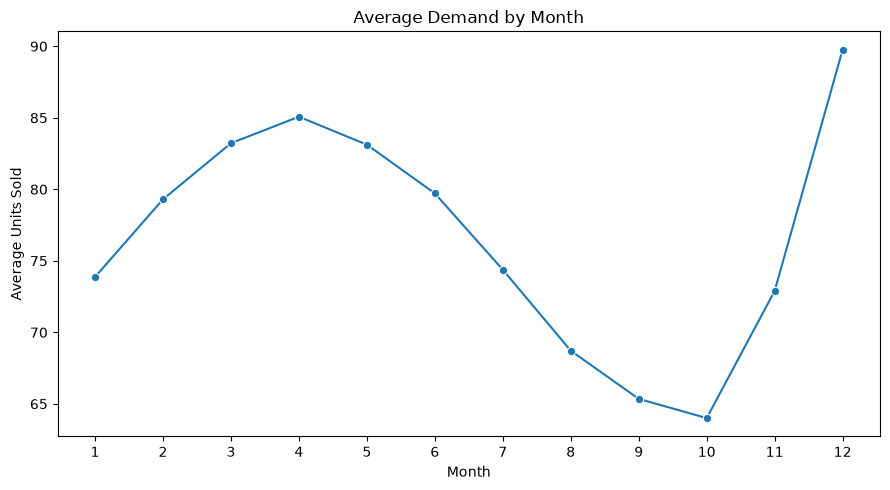


Average demand by promotion:
promotion
0    73.988797
1    91.251254
Name: units_sold, dtype: float64


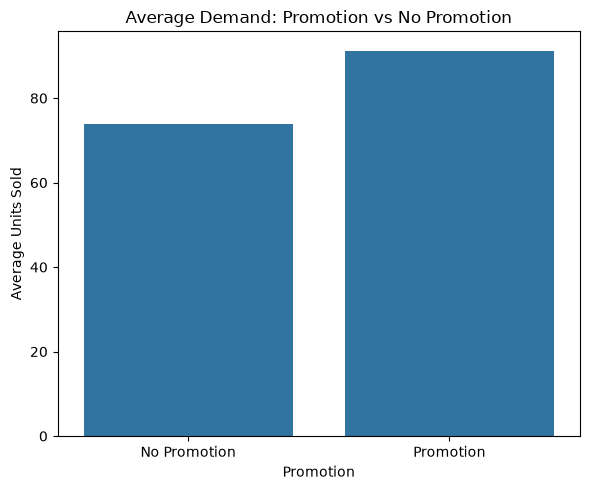

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ---------------------------------------------------------
# Load data
# ---------------------------------------------------------

df = pd.read_csv(
    "../data/raw/sales.csv",
    parse_dates=["date"],
)

df.head()


# ---------------------------------------------------------
# Basic dataset information
# ---------------------------------------------------------

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

print("\nSummary statistics:")
print(df.describe())


# ---------------------------------------------------------
# 1. Overall demand over time
# ---------------------------------------------------------

daily = (
    df.groupby("date", as_index=False)["units_sold"]
    .sum()
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=daily,
    x="date",
    y="units_sold",
)

plt.title("Overall Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 2. Average demand by category
# ---------------------------------------------------------

category_demand = (
    df.groupby("category", as_index=False)["units_sold"]
    .mean()
    .sort_values("units_sold", ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=category_demand,
    x="category",
    y="units_sold",
)

plt.title("Average Demand by Category")
plt.xlabel("Category")
plt.ylabel("Average Units Sold")
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 3. Average demand by product
# ---------------------------------------------------------

product_demand = (
    df.groupby(
        ["product_id", "category"],
        as_index=False,
    )["units_sold"]
    .mean()
    .sort_values("units_sold", ascending=False)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=product_demand,
    x="product_id",
    y="units_sold",
)

plt.title("Average Demand by Product")
plt.xlabel("Product ID")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 4. Price vs demand
# ---------------------------------------------------------

sample = df.sample(
    min(3000, len(df)),
    random_state=42,
)

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=sample,
    x="price",
    y="units_sold",
    alpha=0.35,
)

plt.title("Price vs Demand")
plt.xlabel("Price")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 5. Competitor price vs demand
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=sample,
    x="competitor_price",
    y="units_sold",
    alpha=0.35,
)

plt.title("Competitor Price vs Demand")
plt.xlabel("Competitor Price")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 6. Demand by weekday
# ---------------------------------------------------------

df["weekday"] = df["date"].dt.day_name()

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="weekday",
    y="units_sold",
    order=weekday_order,
)

plt.title("Demand by Weekday")
plt.xlabel("Day of Week")
plt.ylabel("Units Sold")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 7. Monthly seasonality
# ---------------------------------------------------------

df["month"] = df["date"].dt.month

monthly_demand = (
    df.groupby("month", as_index=False)["units_sold"]
    .mean()
)

plt.figure(figsize=(9, 5))

sns.lineplot(
    data=monthly_demand,
    x="month",
    y="units_sold",
    marker="o",
)

plt.title("Average Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Units Sold")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 8. Promotion impact
# ---------------------------------------------------------

promotion_summary = (
    df.groupby("promotion")["units_sold"]
    .mean()
)

print("\nAverage demand by promotion:")
print(promotion_summary)


plt.figure(figsize=(6, 5))

sns.barplot(
    x=promotion_summary.index,
    y=promotion_summary.values,
)

plt.title("Average Demand: Promotion vs No Promotion")
plt.xlabel("Promotion")
plt.ylabel("Average Units Sold")
plt.xticks([0, 1], ["No Promotion", "Promotion"])
plt.tight_layout()
plt.show()